<a href="https://colab.research.google.com/github/JosNavarro/Invest2026-27/blob/main/GRUSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import gc
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import h5py
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/B0006train.mat'
battery_id_train = 'B0006'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
def graficar_modelo(actual, predicted, battery_id, r2_score):
    """
    Genera la gráfica de degradación con fondo blanco y estilo clásico,
    exactamente igual a la imagen de referencia.
    """
    # Usar el mismo tamaño ancho que en tu imagen
    fig, ax = plt.subplots(figsize=(12, 7))

    # Fondo blanco
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Curvas de datos: Azul (Real) y Rojo (Predicción)
    ax.plot(actual, label=f'Actual Capacity (NASA {battery_id})', color='blue', linewidth=2)
    ax.plot(predicted, label='GRU Predicted Capacity', color='red', linewidth=2)

    # Umbral de Fin de Vida (Línea punteada negra)
    ax.axhline(y=1.4, color='black', linestyle=':', label='End of Life Threshold (1.4 Ah)')

    # Título y etiquetas con texto en negro
    ax.set_title(f'Battery Degradation: Actual vs. GRU Prediction ($R^2$: {r2_score:.4f})', color='black', fontsize=13)
    ax.set_xlabel('Cycles (Sliding Windows)', color='black', fontsize=11)
    ax.set_ylabel('Capacity (Ah)', color='black', fontsize=11)

    # Configuración de ejes
    ax.tick_params(colors='black')

    # Leyenda en la esquina superior derecha con fondo blanco
    ax.legend(facecolor='white', edgecolor='lightgray', labelcolor='black', loc='upper right')

    # Cuadrícula: Líneas punteadas grises
    ax.grid(True, linestyle='--', color='silver', alpha=0.8)

    # Bordes del gráfico en negro
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

    plt.tight_layout()
    plt.show()

In [35]:
with h5py.File(data_path, 'r') as f:
  X_raw = np.array(f['X_3D'])
  cap_min = np.array(f['cap_min']).item()
  cap_max = np.array(f['cap_max']).item()

In [36]:
# h5py reads it as [features, window_size, windows]
# We transpose it back to [windows, window_size, features] -> (2, 1, 0)
X_corrected = np.transpose(X_raw, (2, 1, 0))
print(f"Corrected Tensor shape: {X_corrected.shape}")

Corrected Tensor shape: (50236, 50, 8)


In [37]:
# ==========================================
# 1. Preparación de los Tensores (Fuga de Datos Corregida)
# ==========================================
print("Preparando datos de entrenamiento...")
# Asegúrate de que X_corrected sea el tensor transpuesto de tu B0005
X_train_data = X_corrected[:, :, :7] # SOLO columnas 0 a 6 (Sensores)
Y_train_data = X_corrected[:, -1, 7] # SOLO columna 7 del último ciclo (Capacidad)

X_train_tensor = torch.tensor(X_train_data, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_data, dtype=torch.float32).unsqueeze(1)

print(f"Tensor X (Entrada): {X_train_tensor.shape} -> [Ventanas, 50 ciclos, 7 features]")
print(f"Tensor Y (Objetivo): {Y_train_tensor.shape} -> [Ventanas, 1 predicción]")

# Crear el DataLoader para procesar en lotes de 64
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Preparando datos de entrenamiento...
Tensor X (Entrada): torch.Size([50236, 50, 7]) -> [Ventanas, 50 ciclos, 7 features]
Tensor Y (Objetivo): torch.Size([50236, 1]) -> [Ventanas, 1 predicción]


In [38]:
class ModularAttentionGRU(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, output_size=1):
        super(ModularAttentionGRU, self).__init__()

        self.hidden_size = hidden_size
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0
        )
        self.attention = nn.Linear(hidden_size, 1)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, return_stages=False):

        # ETAPA 1: Extracción de Características (GRU)

        # La GRU procesa los 50 ciclos y extrae 64 características de cada uno.
        gru_out, h_n = self.gru(x)

        # ETAPA 2: Puntuación Cruda (Atención)
        # La red lineal evalúa qué tan importante es cada uno de los 50 pasos.
        attn_scores = self.attention(gru_out)


        # ETAPA 3: Distribución de Pesos (Softmax)
        # Convierte las puntuaciones crudas en porcentajes (0 a 1) que suman 100%.
        attn_weights = F.softmax(attn_scores, dim=1)

        # ETAPA 4: El Vector de Contexto
        # Multiplica la salida de la GRU por su "porcentaje de importancia" y lo suma todo.
        weighted_out = gru_out * attn_weights
        context_vector = torch.sum(weighted_out, dim=1)

        # ETAPA 5: Predicción
        # Comprime el vector de contexto enriquecido en un solo número (Capacidad).
        prediction = self.fc(context_vector)

        # En caso de querer ver alguna parte en especifico
        if return_stages:
            stages = {
                "1_gru_out": gru_out,
                "2_attn_scores": attn_scores,
                "3_attn_weights": attn_weights,
                "4_context_vector": context_vector
            }
            return prediction, stages

        return prediction

model = ModularAttentionGRU(input_size=7, hidden_size=64, num_layers=2, output_size=1)

print("GRU Model Architecture defined successfully!")
print(model)

GRU Model Architecture defined successfully!
ModularAttentionGRU(
  (gru): GRU(7, 64, num_layers=2, batch_first=True, dropout=0.3)
  (attention): Linear(in_features=64, out_features=1, bias=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [39]:
# ==========================================
# 1. Preparación de los Tensores (Fuga de Datos Corregida)
# ==========================================
print("Preparando datos de entrenamiento...")
# Asegúrate de que X_corrected sea el tensor transpuesto de tu B0005
X_train_data = X_corrected[:, :, :7] # SOLO columnas 0 a 6 (Sensores)
Y_train_data = X_corrected[:, -1, 7] # SOLO columna 7 del último ciclo (Capacidad)

X_train_tensor = torch.tensor(X_train_data, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_data, dtype=torch.float32).unsqueeze(1)

print(f"Tensor X (Entrada): {X_train_tensor.shape} -> [Ventanas, 50 ciclos, 7 features]")
print(f"Tensor Y (Objetivo): {Y_train_tensor.shape} -> [Ventanas, 1 predicción]")

# Crear el DataLoader para procesar en lotes de 64
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Preparando datos de entrenamiento...
Tensor X (Entrada): torch.Size([50236, 50, 7]) -> [Ventanas, 50 ciclos, 7 features]
Tensor Y (Objetivo): torch.Size([50236, 1]) -> [Ventanas, 1 predicción]


In [40]:
# ==========================================
# 2. Configuración del Modelo y Optimizador
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

# Instanciamos el modelo con input_size=7
model = ModularAttentionGRU(input_size=7, hidden_size=64, num_layers=2, output_size=1).to(device)

# Función de pérdida (MSE) y Optimizador (Adam)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay = 1e-5)

Entrenando en: cuda


In [41]:
# ==========================================
# 3. Bucle de Entrenamiento
# ==========================================
num_epochs = 50 # Number of times to loop through the entire dataset
loss_history = [] # Lista extra para guardar la historia y poder graficarla

# Set the model to training mode (enables dropout, etc.)
model.train()

print("Starting training...")

for epoch in range(num_epochs):
    epoch_loss = 0.0

    # Loop through the batches in our DataLoader
    for batch_X, batch_Y in train_loader:
        # Move the batch data to the same device as the model
        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer.zero_grad()

        # Step 2: Forward pass (the model makes its predictions)
        predictions = model(batch_X)

        # Step 3: Calculate the error (compare predictions to the actual targets)
        loss = criterion(predictions, batch_Y)

        # Step 4: Backward pass (calculate the math needed to correct the error)
        loss.backward()

        # Step 5: Update the model's weights based on the backward pass
        optimizer.step()

        # Add up the loss to track progress
        epoch_loss += loss.item()

    # Calculate the average loss across all batches for this epoch
    avg_epoch_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_epoch_loss) # Guardamos el dato de esta época

    # Print the progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss (MSE): {avg_epoch_loss:.6f}')

print("Training complete!")

Starting training...
Epoch [1/50], Average Loss (MSE): 0.005480
Epoch [10/50], Average Loss (MSE): 0.000856
Epoch [20/50], Average Loss (MSE): 0.000837
Epoch [30/50], Average Loss (MSE): 0.000824
Epoch [40/50], Average Loss (MSE): 0.000821
Epoch [50/50], Average Loss (MSE): 0.000809
Training complete!


In [42]:
# ==========================================
# 4. Inferencia sobre los datos de Entrenamiento (OOM Safe)
# ==========================================
# Limpiar memoria de la GPU
torch.cuda.empty_cache()
gc.collect()

print("Generando predicciones finales sobre los datos de entrenamiento...")
model.eval()
all_train_predictions = []
batch_size = 256 # Tamaño de bocado seguro
num_train_samples = X_train_tensor.shape[0]

with torch.no_grad():
    for i in range(0, num_train_samples, batch_size):
        batch_X = X_train_tensor[i : i + batch_size].to(device)
        batch_preds = model(batch_X)
        all_train_predictions.append(batch_preds.cpu().numpy())

train_preds_numpy = np.concatenate(all_train_predictions, axis=0)

Generando predicciones finales sobre los datos de entrenamiento...


In [43]:
# ==========================================
# 5. Desnormalizar Datos
# ==========================================
# Regresar los valores de la escala 0-1 a la escala real (Amperios-hora)
# NOTA: Asegúrate de que las variables cap_max y cap_min estén cargadas en memoria
actual_train_capacity = (Y_train_data * (cap_max - cap_min)) + cap_min
predicted_train_capacity = (train_preds_numpy.flatten() * (cap_max - cap_min)) + cap_min

In [44]:
# ==========================================
# 6. Calcular las 4 Métricas de Rendimiento
# ==========================================
train_mse = mean_squared_error(actual_train_capacity, predicted_train_capacity)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(actual_train_capacity, predicted_train_capacity)
train_r2 = r2_score(actual_train_capacity, predicted_train_capacity)

# Imprimir el reporte
print("-" * 40)
print(f"REPORTE DE RENDIMIENTO: Batería B0005 (ENTRENAMIENTO)")
print("-" * 40)
print(f"MSE  (Mean Squared Error):      {train_mse:.6f}")
print(f"RMSE (Root Mean Squared Error): {train_rmse:.6f} Ah")
print(f"MAE  (Mean Absolute Error):     {train_mae:.6f} Ah")
print(f"R^2  (R-Squared):               {train_r2:.4f}")
print("-" * 40)

----------------------------------------
REPORTE DE RENDIMIENTO: Batería B0005 (ENTRENAMIENTO)
----------------------------------------
MSE  (Mean Squared Error):      0.000571
RMSE (Root Mean Squared Error): 0.023901 Ah
MAE  (Mean Absolute Error):     0.017375 Ah
R^2  (R-Squared):               0.9895
----------------------------------------


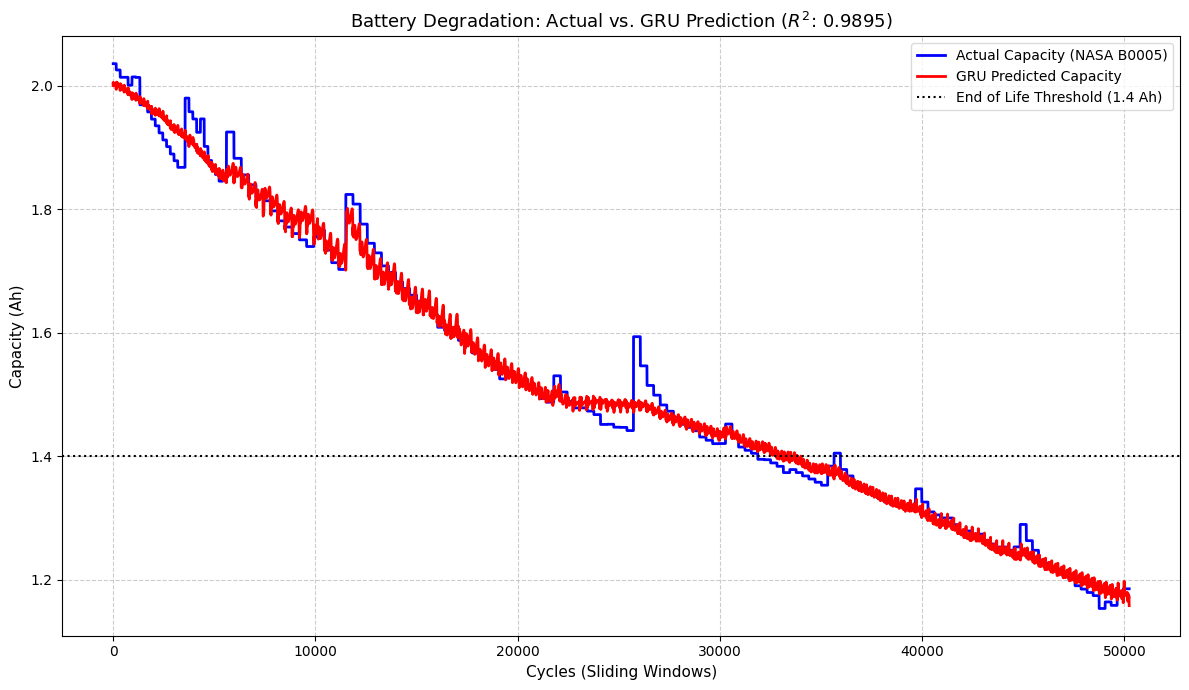

In [45]:
# ==========================================
# 7. Visualización Final (Predicción vs Realidad)
# ==========================================
# ... (código donde calculas train_r2, train_mse, etc.) ...

# Llamada a la función maestra
graficar_modelo(actual_train_capacity, predicted_train_capacity, 'B0005', train_r2)

# Evaluation with other datasets


In [58]:
# ==========================================
# CONFIGURACIÓN INICIAL (Testing)
# ==========================================
battery_id = 'B0007'
test_file_path = f'/content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/{battery_id}test.mat'

# ==========================================
# 1. Cargar Datos desde MATLAB
# ==========================================
print(f"Cargando archivo: {test_file_path}...")
with h5py.File(test_file_path, 'r') as f:
    X_raw_test = np.array(f['X_3D'])
    # Recuperamos los parámetros de normalización de la base maestra
    cap_min = np.array(f['cap_min']).item()
    cap_max = np.array(f['cap_max']).item()



Cargando archivo: /content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/B0007test.mat...


In [59]:
# ==========================================
# 2. Corregir Formato y Separar Datos (Fuga de Datos Corregida)
# ==========================================
# ¡ESTE ES EL PASO QUE FALTABA! Arregla el orden de las dimensiones de MATLAB a Python
X_corrected_test = np.transpose(X_raw_test, (2, 1, 0))
print(f"Forma original del tensor (corregida): {X_corrected_test.shape}")

# Separamos los 7 sensores (Entrada) de la Capacidad Real (Objetivo)
X_test_data = X_corrected_test[:, :, :7]
Y_test_data = X_corrected_test[:, -1, 7]

# Convertimos a tensores de PyTorch
X_test_tensor = torch.tensor(X_test_data, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_data, dtype=torch.float32).unsqueeze(1)


Forma original del tensor (corregida): (50236, 50, 8)


In [60]:
# ==========================================
# 2. Inferencia por Lotes (OOM Safe)
# ==========================================
# Limpiamos la memoria de la tarjeta gráfica
torch.cuda.empty_cache()
gc.collect()

print(f"Generando predicciones para la batería {battery_id}...")
model.eval()
all_predictions = []
batch_size = 256 # Tamaño de lote seguro para la memoria
num_samples = X_test_tensor.shape[0]

with torch.no_grad():
    for i in range(0, num_samples, batch_size):
        batch_X = X_test_tensor[i : i + batch_size].to(device)
        batch_preds = model(batch_X)
        all_predictions.append(batch_preds.cpu().numpy())

# Unimos todas las predicciones
preds_numpy = np.concatenate(all_predictions, axis=0)

Generando predicciones para la batería B0007...


In [61]:
# ==========================================
# 3. Desnormalizar Datos
# ==========================================
# Regresamos los valores a su escala original de Amperios-hora (Ah)
# (Asegúrate de que cap_max y cap_min de tu base B0005 estén cargados en memoria)
actual_capacity = (Y_test_data * (cap_max - cap_min)) + cap_min
predicted_capacity = (preds_numpy.flatten() * (cap_max - cap_min)) + cap_min

In [62]:
# ==========================================
# 4. Calcular Métricas de Rendimiento
# ==========================================
test_mse = mean_squared_error(actual_capacity, predicted_capacity)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(actual_capacity, predicted_capacity)
test_r2 = r2_score(actual_capacity, predicted_capacity)

print("-" * 40)
print(f"REPORTE DE RENDIMIENTO: Batería {battery_id} (TESTING)")
print("-" * 40)
print(f"MSE  (Mean Squared Error):      {test_mse:.6f}")
print(f"RMSE (Root Mean Squared Error): {test_rmse:.6f} Ah")
print(f"MAE  (Mean Absolute Error):     {test_mae:.6f} Ah")
print(f"R^2  (R-Squared):               {test_r2:.4f}")
print("-" * 40)

----------------------------------------
REPORTE DE RENDIMIENTO: Batería B0007 (TESTING)
----------------------------------------
MSE  (Mean Squared Error):      0.015418
RMSE (Root Mean Squared Error): 0.124169 Ah
MAE  (Mean Absolute Error):     0.110147 Ah
R^2  (R-Squared):               0.3380
----------------------------------------


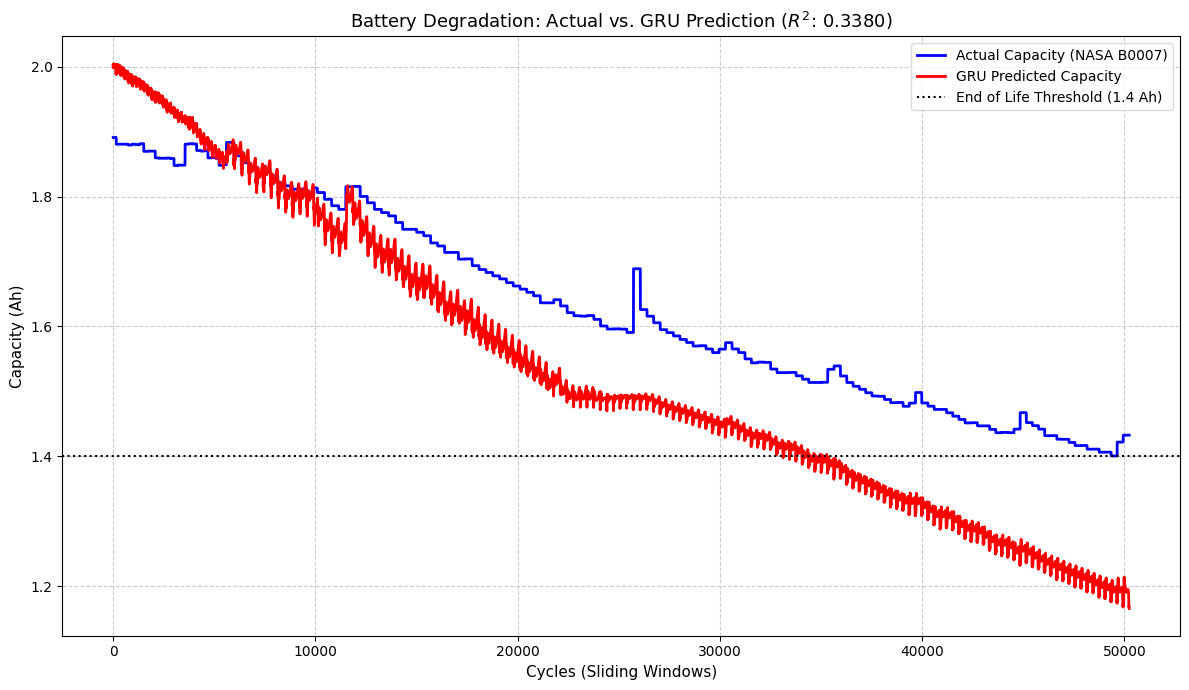

In [63]:
# ==========================================
# 5. Visualización Final (Formato Clásico Blanco)
# ==========================================


graficar_modelo(actual_capacity, predicted_capacity, battery_id, test_r2)